In [2]:
import pandas as pd

In [3]:
%%time
df_af = pd.read_excel("conflict data/Africa_aggregated_data_up_to-2026-02-28.xlsx")
df_as = pd.read_excel("conflict data/Asia-Pacific_aggregated_data_up_to-2026-02-28.xlsx")
df_eu = pd.read_excel("conflict data/Europe-Central-Asia_aggregated_data_up_to-2026-02-28.xlsx")
df_sa = pd.read_excel("conflict data/Latin-America-the-Caribbean_aggregated_data_up_to-2026-02-28.xlsx")
df_me = pd.read_excel("conflict data/Middle-East_aggregated_data_up_to-2026-02-28.xlsx")
df_na = pd.read_excel("conflict data/US-and-Canada_aggregated_data_up_to-2026-02-28.xlsx")

CPU times: total: 1min 28s
Wall time: 1min 28s


In [4]:
df = pd.concat([df_af, df_as, df_eu, df_sa, df_me, df_na], axis = 0, ignore_index = True)

In [5]:
df.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,2004-10-23,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,2,NaN,Political violence,47.0,26.4839,-1.388
1,2005-04-23,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,0,NaN,Political violence,47.0,26.4839,-1.388
2,2005-06-25,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,14,NaN,Political violence,47.0,26.4839,-1.388
3,2008-12-13,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,3,NaN,Political violence,47.0,26.4839,-1.388
4,2009-04-18,Northern Africa,Algeria,Adrar,Battles,Armed clash,1,2,NaN,Political violence,47.0,26.4839,-1.388


In [9]:
df.groupby("REGION")["FATALITIES"].sum()

REGION
Antarctica                        0
Caribbean                     18665
Caucasus and Central Asia    212538
Central America               15498
East Asia                       249
Eastern Africa               360578
Europe                       254670
Middle Africa                294508
Middle East                  546493
North America                 68803
Northern Africa              202532
Oceania                        1426
South America                 99520
South Asia                    78520
Southeast Asia               129869
Southern Africa                5237
Western Africa               230478
Name: FATALITIES, dtype: int64

In [16]:
df_map = df.merge(df_region, on="REGION", suffixes=("", "_REGION"))

In [23]:
df_fata = pd.read_excel("conflict data/number_of_reported_fatalities_by_country-year_as-of-06Mar2026.xlsx")
df_civ_fata = pd.read_excel("conflict data/number_of_reported_civilian_fatalities_by_country-year_as-of-06Mar2026.xlsx")

In [27]:
df_fata.groupby("COUNTRY")["FATALITIES"].sum()

COUNTRY
Afghanistan              202014
Akrotiri and Dhekelia         0
Albania                       4
Algeria                   13812
American Samoa                0
                          ...  
Wallis and Futuna             0
Yemen                    166473
Zambia                      356
Zimbabwe                    639
eSwatini                    148
Name: FATALITIES, Length: 245, dtype: int64

In [28]:
df_country = df_fata.groupby("COUNTRY", as_index=False)["FATALITIES"].sum()

C:\Users\Ahmed\AppData\Local\Temp\ipykernel_416\3923095304.py:3: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



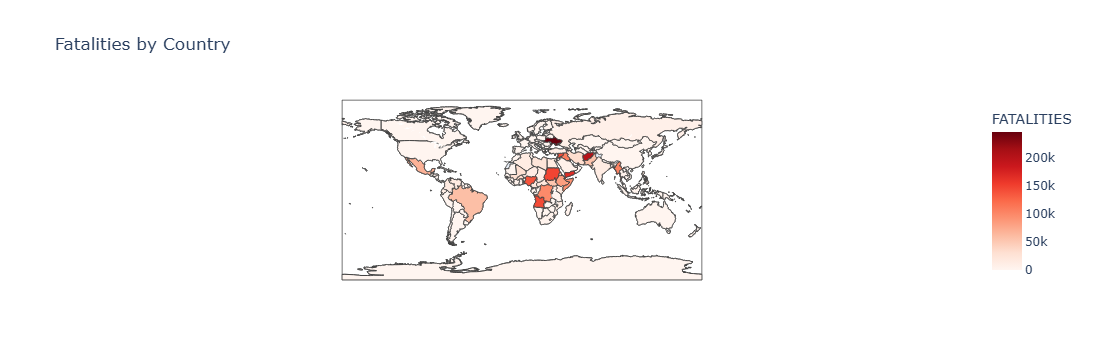

In [29]:
import plotly.express as px

fig = px.choropleth(
    df_country,
    locations="COUNTRY",
    locationmode="country names",
    color="FATALITIES",
    color_continuous_scale="Reds",
    title="Fatalities by Country"
)

fig.show()